# Gridworld Task: Model Comparison
Trains and visualises five prediction-error models on a 7×7 grid-world reversal task.

**Models:** ScalarRPE | OutcomePE | VectorRPE | VectorAPE | TimescaleRPE

Run `python GridworldPE.py` first to generate `./data/gridworld/results.npz`.

In [9]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm, Normalize
import matplotlib.cm as cm
from scipy.ndimage import uniform_filter1d

matplotlib.rcParams.update({
    'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
})

COLORS = {
    'ScalarRPE':   '#1f77b4',
    'OutcomePE':   '#d62728',
    'VectorRPE':   '#2ca02c',
    'VectorAPE':   '#9467bd',
    'TimescaleRPE':'#ff7f0e',
}
MODEL_NAMES = ['ScalarRPE','OutcomePE','VectorRPE','VectorAPE','TimescaleRPE']
ACTION_NAMES = ['North','South','East','West']

## 0  Load data

In [10]:
d = np.load('./data/gridworld/results.npz', allow_pickle=True)

H, W         = int(d['H']), int(d['W'])
N_FEATURES   = int(d['N_FEATURES'])
N_OUT_CH     = int(d['N_OUT_CH'])
EPB          = int(d['EPS_PER_BLOCK'])
N_BLOCKS     = int(d['N_BLOCKS'])
block_goals  = d['block_goals']          # (N_BLOCKS, 2)
block_eps    = d['block_eps']            # episode index at each block start
checkpoints  = d['checkpoints']          # episode indices of checkpoints
PHI          = d['phi_all']              # (N_STATES, N_FEATURES)
TOTAL_EPS    = EPB * N_BLOCKS

def arr(key): return d[key]

print(f'Grid {H}×{W} | {N_BLOCKS} blocks × {EPB} episodes | {len(checkpoints)} checkpoints')
print(f'Block goals: {[tuple(g) for g in block_goals]}')

Grid 7×7 | 8 blocks × 100 episodes | 33 checkpoints
Block goals: [(np.int64(1), np.int64(1)), (np.int64(5), np.int64(5)), (np.int64(1), np.int64(5)), (np.int64(5), np.int64(1)), (np.int64(1), np.int64(1)), (np.int64(5), np.int64(5)), (np.int64(1), np.int64(5)), (np.int64(5), np.int64(1))]


## 1  Task visualisation

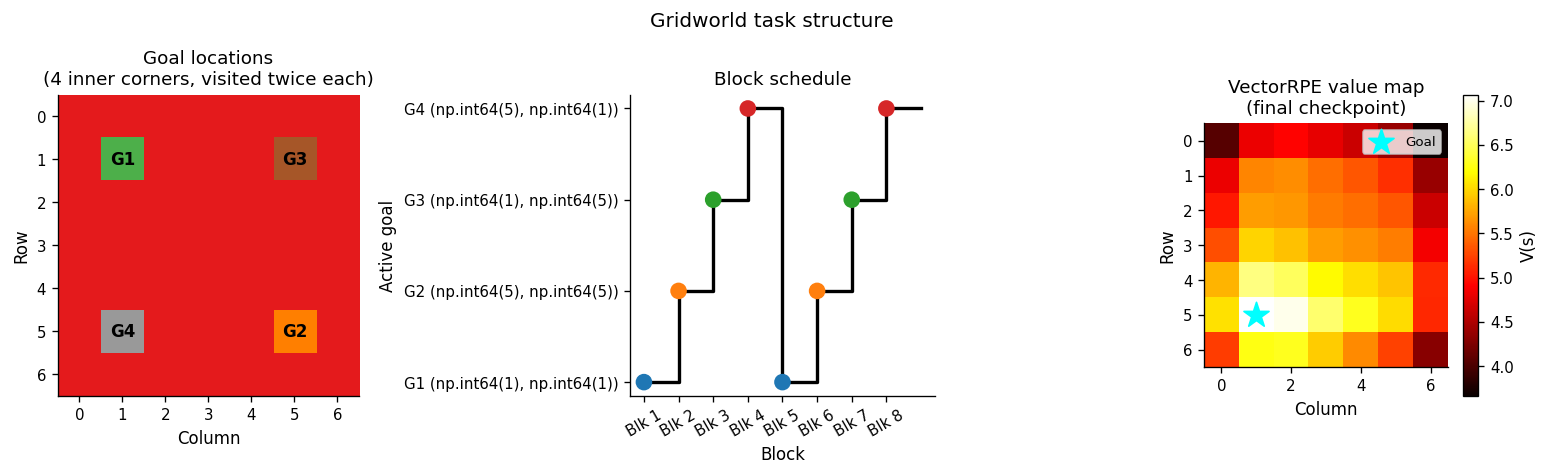

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Gridworld task structure', fontsize=12)

# Panel A: goal schedule
ax = axes[0]
grid_img = np.zeros((H, W))
for blk, (gr, gc) in enumerate(block_goals[:4]):
    grid_img[gr, gc] = blk + 1
im = ax.imshow(grid_img, cmap='Set1', vmin=0, vmax=4, origin='upper')
for gr, gc in block_goals[:4]:
    ax.text(gc, gr, f'G{list(map(tuple,block_goals[:4])).index((gr,gc))+1}',
            ha='center', va='center', fontweight='bold', fontsize=10)
ax.set_title('Goal locations\n(4 inner corners, visited twice each)')
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.set_xticks(range(W)); ax.set_yticks(range(H))

# Panel B: block schedule diagram
ax = axes[1]
goal_idx = [list(map(tuple,block_goals[:4])).index(tuple(g)) for g in block_goals]
ax.step(range(N_BLOCKS+1), goal_idx + [goal_idx[-1]], where='post',
        color='k', lw=2)
ax.scatter(range(N_BLOCKS), goal_idx, s=80,
           c=[f'C{i}' for i in goal_idx], zorder=3)
ax.set_xticks(range(N_BLOCKS))
ax.set_xticklabels([f'Blk {i+1}' for i in range(N_BLOCKS)], rotation=30)
ax.set_yticks([0,1,2,3])
ax.set_yticklabels([f'G{i+1} {tuple(block_goals[i])}' for i in range(4)])
ax.set_title('Block schedule')
ax.set_xlabel('Block'); ax.set_ylabel('Active goal')

# Panel C: example learned value map (last block, VectorRPE)
ax = axes[2]
last_ckpt = len(checkpoints) - 1
vmap = arr('VectorRPE__val_maps')[last_ckpt]
goal_r, goal_c = block_goals[-1]
im2 = ax.imshow(vmap, cmap='hot', origin='upper')
ax.scatter([goal_c], [goal_r], marker='*', s=250, c='cyan', zorder=5, label='Goal')
plt.colorbar(im2, ax=ax, label='V(s)')
ax.set_title('VectorRPE value map\n(final checkpoint)')
ax.set_xlabel('Column'); ax.set_ylabel('Row')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('./data/gridworld/fig1_task.pdf', bbox_inches='tight')
plt.show()

## 2  Learning curves: steps per episode and success rate

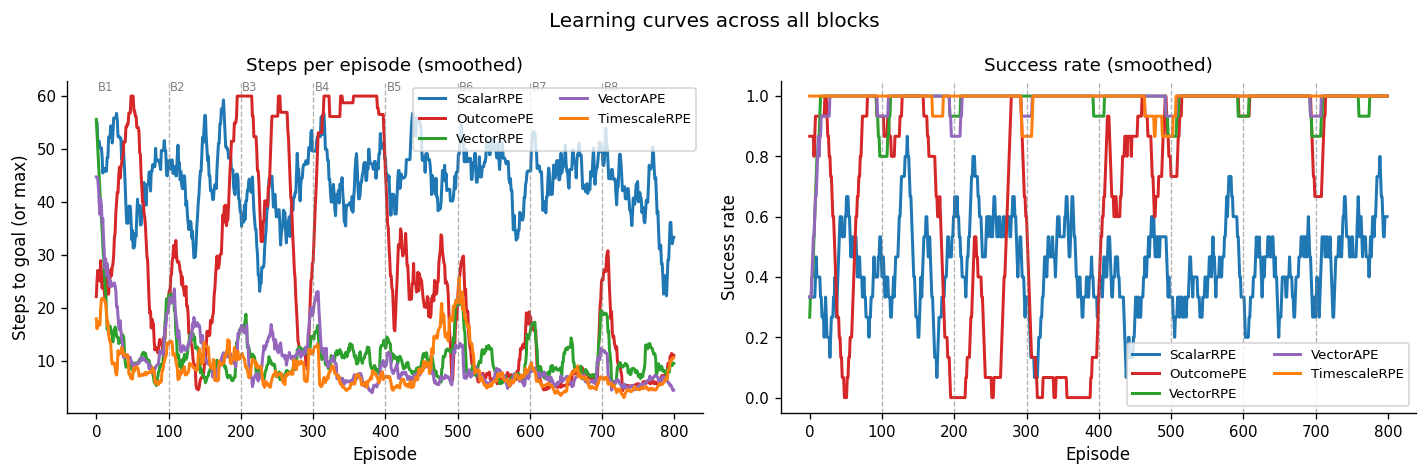

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Learning curves across all blocks', fontsize=12)
smooth = lambda x, w=15: uniform_filter1d(x.astype(float), size=w)

for name in MODEL_NAMES:
    steps   = arr(f'{name}__steps')
    success = arr(f'{name}__success')
    eps     = np.arange(TOTAL_EPS)
    axes[0].plot(eps, smooth(steps),   color=COLORS[name], label=name, lw=1.8)
    axes[1].plot(eps, smooth(success), color=COLORS[name], label=name, lw=1.8)

for ax in axes:
    for be in block_eps[1:]:
        ax.axvline(be, color='gray', lw=0.8, ls='--', alpha=0.6)
    ax.set_xlabel('Episode')
    ax.legend(fontsize=8, ncol=2)

axes[0].set_ylabel('Steps to goal (or max)'); axes[0].set_title('Steps per episode (smoothed)')
axes[1].set_ylabel('Success rate');           axes[1].set_title('Success rate (smoothed)')

# Annotate block numbers
for i, be in enumerate(block_eps):
    axes[0].text(be + 2, axes[0].get_ylim()[1]*0.97, f'B{i+1}', fontsize=7, color='gray')

plt.tight_layout()
plt.savefig('./data/gridworld/fig2_learning_curves.pdf', bbox_inches='tight')
plt.show()

## 3  TD loss over training

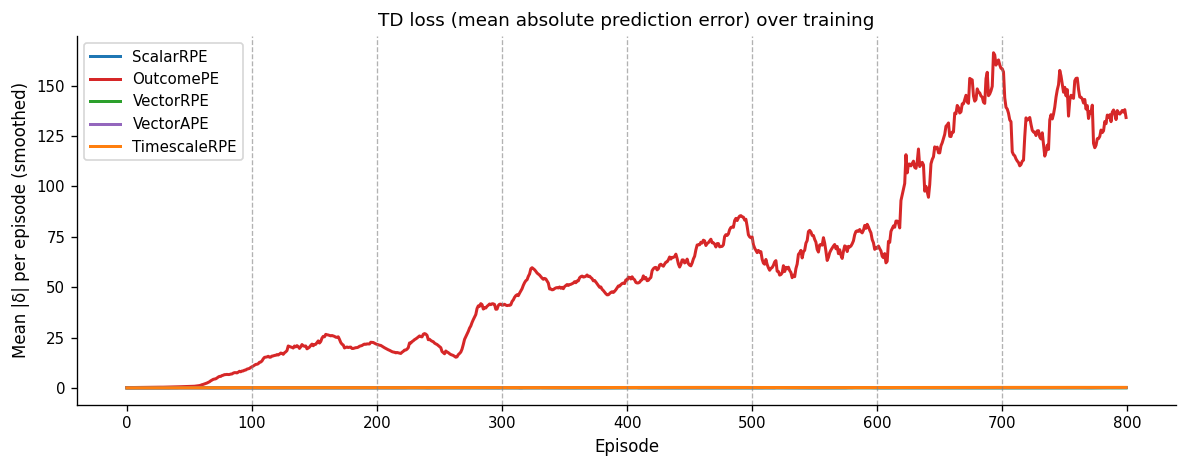

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
for name in MODEL_NAMES:
    loss = arr(f'{name}__td_loss')
    ax.plot(smooth(loss), color=COLORS[name], label=name, lw=1.8)
for be in block_eps[1:]:
    ax.axvline(be, color='gray', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('Episode'); ax.set_ylabel('Mean |δ| per episode (smoothed)')
ax.set_title('TD loss (mean absolute prediction error) over training')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('./data/gridworld/fig3_td_loss.pdf', bbox_inches='tight')
plt.show()

## 4  Value map evolution (early → mid → late in Block 1 and Block 5)

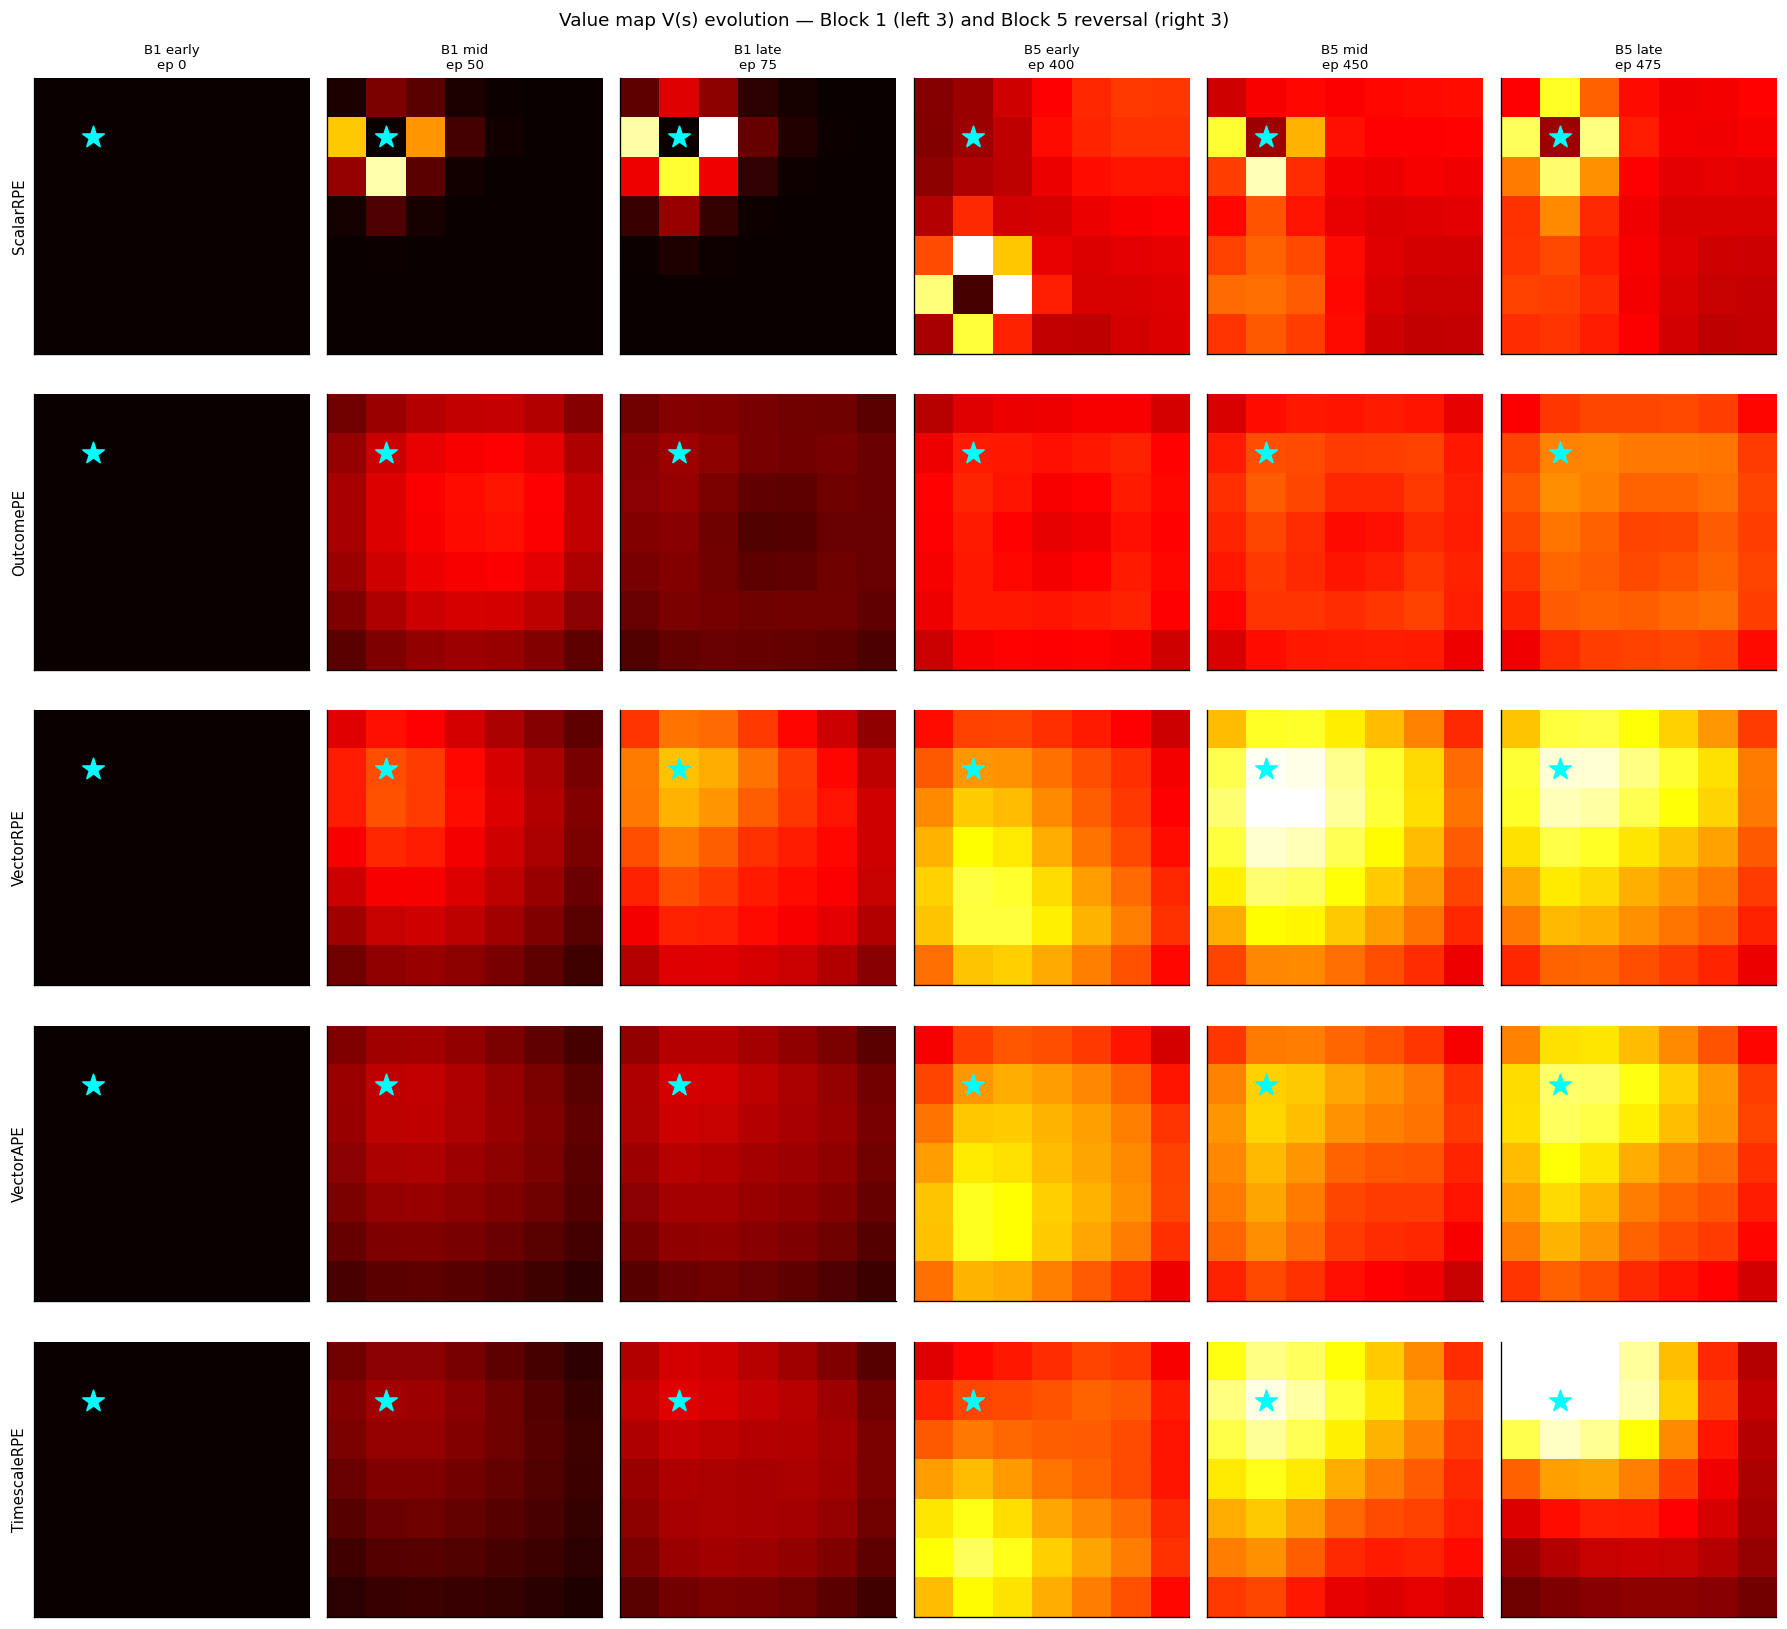

In [14]:
# Pick 3 checkpoints inside block 1 and 3 inside block 5
def ckpts_in_block(blk):
    start = blk * EPB
    end   = (blk + 1) * EPB
    idx   = np.where((checkpoints >= start) & (checkpoints < end))[0]
    # early, mid, late
    return idx[[0, len(idx)//2, -1]]

blk1_ckpts = ckpts_in_block(0)
blk5_ckpts = ckpts_in_block(4)

n_models = len(MODEL_NAMES)
fig, axes = plt.subplots(n_models, 6, figsize=(15, 2.8 * n_models))
fig.suptitle('Value map V(s) evolution — Block 1 (left 3) and Block 5 reversal (right 3)', fontsize=11)

for row, name in enumerate(MODEL_NAMES):
    vmaps = arr(f'{name}__val_maps')
    vmax  = np.percentile(np.abs(vmaps), 98)

    for col, (ci, blk_label) in enumerate(
            [(blk1_ckpts[0], 'B1 early'), (blk1_ckpts[1], 'B1 mid'), (blk1_ckpts[2], 'B1 late'),
             (blk5_ckpts[0], 'B5 early'), (blk5_ckpts[1], 'B5 mid'), (blk5_ckpts[2], 'B5 late')]):

        ax   = axes[row, col]
        vmap = vmaps[ci]
        blk  = 0 if col < 3 else 4
        gr, gc = block_goals[blk]

        im = ax.imshow(vmap, cmap='hot', origin='upper', vmin=0, vmax=vmax)
        ax.scatter([gc], [gr], marker='*', s=180, c='cyan', zorder=5)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(name, fontsize=9)
        if row == 0:
            ax.set_title(f'{blk_label}\nep {checkpoints[ci]}', fontsize=8)

plt.tight_layout()
plt.savefig('./data/gridworld/fig4_value_maps.pdf', bbox_inches='tight')
plt.show()

## 5  DA signal maps: mean |δ| per state

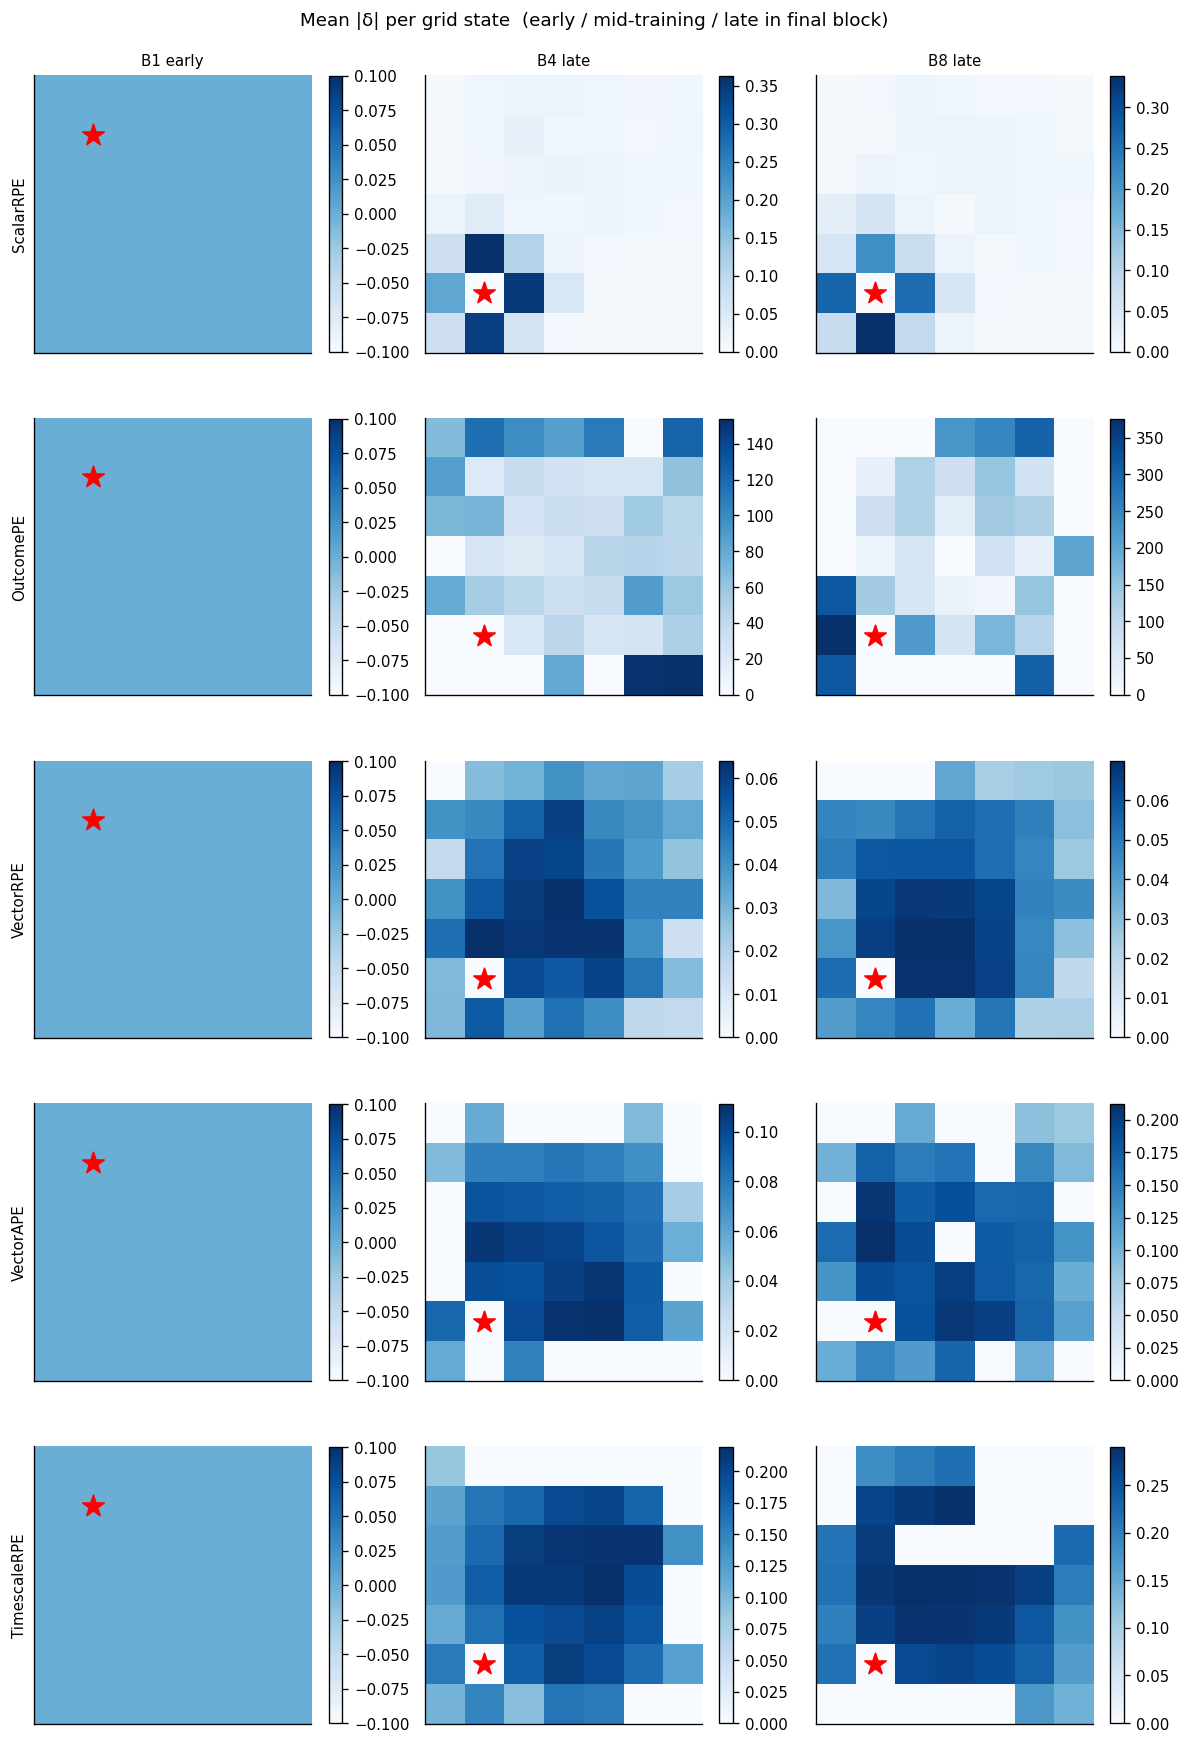

In [15]:
fig, axes = plt.subplots(n_models, 3, figsize=(10, 3 * n_models))
fig.suptitle('Mean |δ| per grid state  (early / mid-training / late in final block)', fontsize=11)

final_blk_ckpts = ckpts_in_block(N_BLOCKS - 1)
three_ckpts     = [blk1_ckpts[0], ckpts_in_block(3)[-1], final_blk_ckpts[-1]]
col_labels      = ['B1 early', 'B4 late', 'B8 late']

for row, name in enumerate(MODEL_NAMES):
    damaps = arr(f'{name}__da_maps')
    for col, (ci, lbl) in enumerate(zip(three_ckpts, col_labels)):
        ax  = axes[row, col]
        blk = [0, 3, 7][col]
        gr, gc = block_goals[blk]
        dmap = damaps[ci]
        im = ax.imshow(dmap, cmap='Blues', origin='upper')
        ax.scatter([gc], [gr], marker='*', s=180, c='red', zorder=5)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0: ax.set_ylabel(name, fontsize=9)
        if row == 0: ax.set_title(lbl, fontsize=9)
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('./data/gridworld/fig5_da_maps.pdf', bbox_inches='tight')
plt.show()

## 6  OutcomePE: per-channel value maps (pessimistic → optimistic)

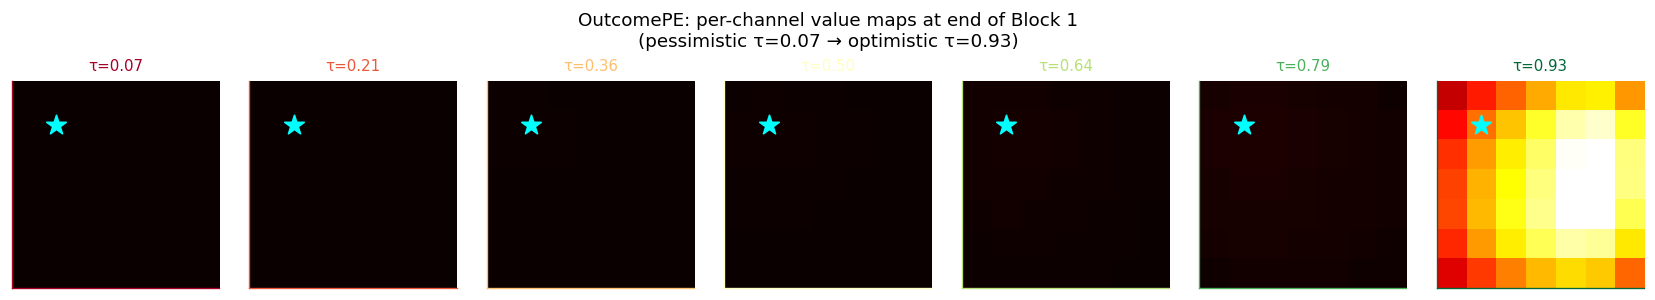

In [16]:
taus = np.array([(2*i-1)/(2*N_OUT_CH) for i in range(1, N_OUT_CH+1)])
chan_maps = arr('OutcomePE__chan_val_maps')   # (N_ckpts, N_OUT_CH, H, W)
ci_late   = blk1_ckpts[-1]                   # end of block 1
gr, gc    = block_goals[0]

fig, axes = plt.subplots(1, N_OUT_CH, figsize=(14, 2.5))
fig.suptitle('OutcomePE: per-channel value maps at end of Block 1\n'
             '(pessimistic τ=0.07 → optimistic τ=0.93)', fontsize=11)

cmap_t = plt.cm.RdYlGn
vmax   = np.percentile(np.abs(chan_maps[ci_late]), 99)
for ch in range(N_OUT_CH):
    ax = axes[ch]
    im = ax.imshow(chan_maps[ci_late, ch], cmap='hot', origin='upper', vmin=0, vmax=vmax)
    ax.scatter([gc], [gr], marker='*', s=150, c='cyan', zorder=5)
    ax.set_xticks([]); ax.set_yticks([])
    col = cmap_t(ch / (N_OUT_CH - 1))
    ax.set_title(f'τ={taus[ch]:.2f}', fontsize=9, color=col)
    ax.spines['bottom'].set_color(col); ax.spines['left'].set_color(col)

plt.tight_layout()
plt.savefig('./data/gridworld/fig6_outcome_channels.pdf', bbox_inches='tight')
plt.show()

## 7  TimescaleRPE: β map evolution across training

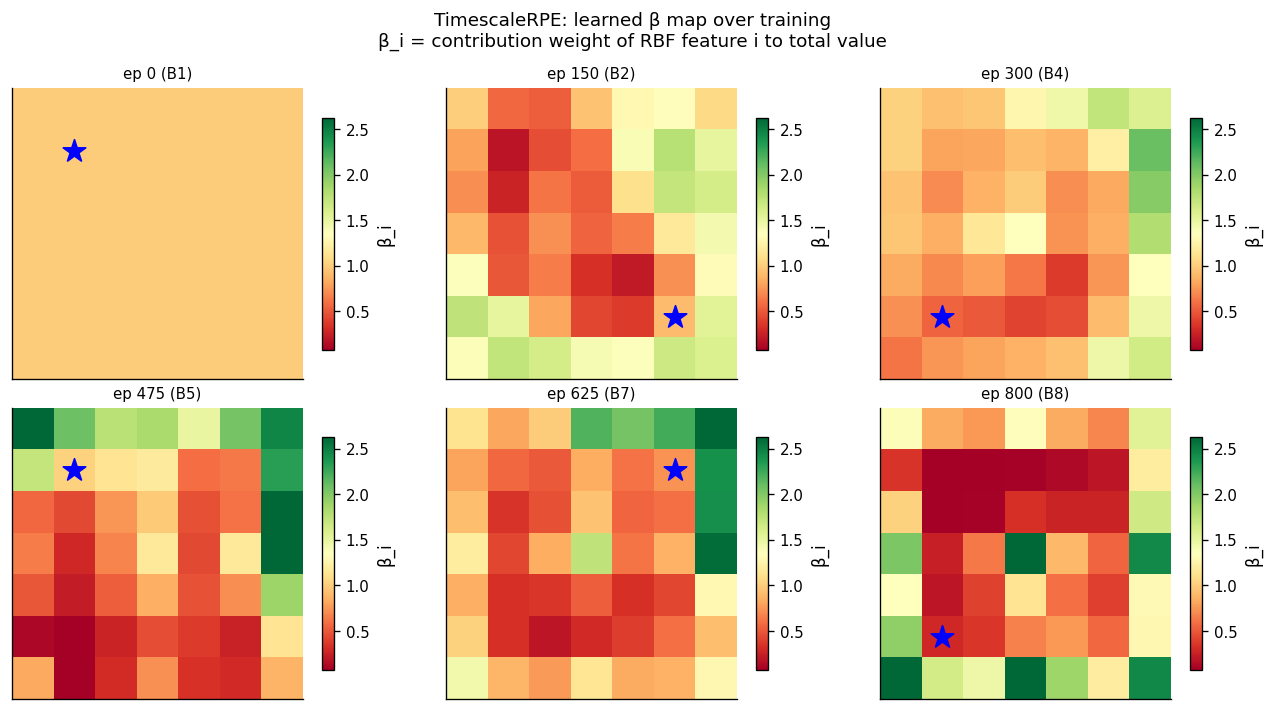

In [17]:
beta_maps = arr('TimescaleRPE__beta_maps')  # (N_ckpts, H, W)

# 6 checkpoints spanning full training
idx6 = np.linspace(0, len(checkpoints)-1, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
fig.suptitle('TimescaleRPE: learned β map over training\n'
             'β_i = contribution weight of RBF feature i to total value', fontsize=11)
axes = axes.ravel()

bmax = np.percentile(beta_maps, 98)
bmin = np.percentile(beta_maps, 2)

for ax_i, ci in enumerate(idx6):
    ax  = axes[ax_i]
    blk = np.searchsorted(block_eps, checkpoints[ci], side='right') - 1
    blk = max(0, min(N_BLOCKS-1, blk))
    gr, gc = block_goals[blk]
    im  = ax.imshow(beta_maps[ci], cmap='RdYlGn', origin='upper',
                    vmin=bmin, vmax=bmax)
    ax.scatter([gc], [gr], marker='*', s=200, c='blue', zorder=5)
    ax.set_title(f'ep {checkpoints[ci]} (B{blk+1})', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.8, label='β_i')

plt.tight_layout()
plt.savefig('./data/gridworld/fig7_beta_maps.pdf', bbox_inches='tight')
plt.show()

## 8  VectorAPE: directional DA maps

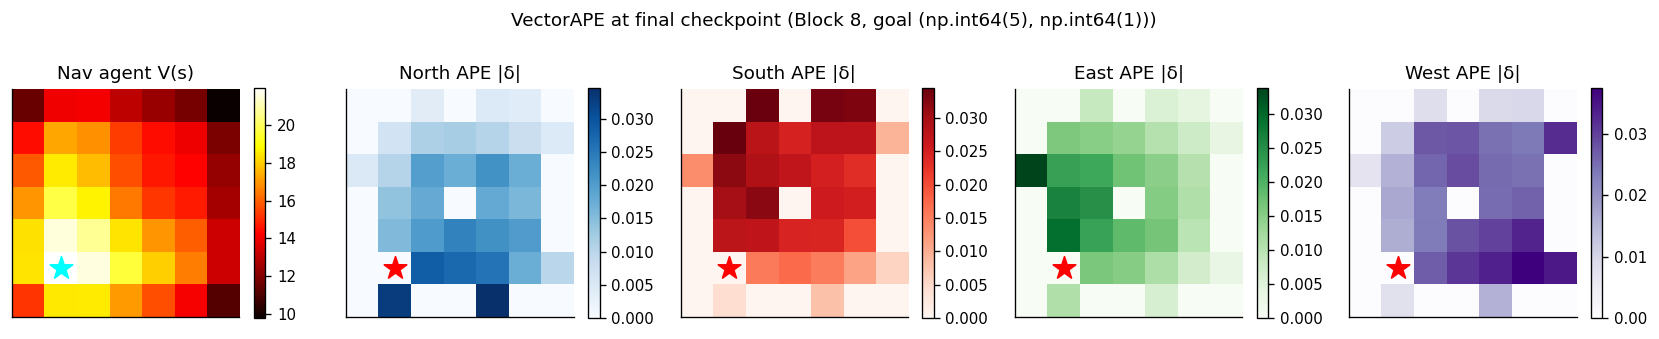

In [18]:
ape_da = arr('VectorAPE__ape_da_maps')   # (N_ckpts, 4, H, W)
nav_vm = arr('VectorAPE__nav_val_maps')  # (N_ckpts, H, W)

# Show final checkpoint for each of 4 directions + nav value
ci_fin = len(checkpoints) - 1
gr, gc = block_goals[-1]

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
fig.suptitle(f'VectorAPE at final checkpoint (Block 8, goal {tuple(block_goals[-1])})', fontsize=11)

# Nav value map
ax = axes[0]
im = ax.imshow(nav_vm[ci_fin], cmap='hot', origin='upper')
ax.scatter([gc],[gr],marker='*',s=200,c='cyan',zorder=5)
ax.set_title('Nav agent V(s)'); ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=ax, shrink=0.8)

# Directional APE maps
dir_cmaps = ['Blues','Reds','Greens','Purples']
for d_idx, (dname, dcmap) in enumerate(zip(Action_NAMES if 'Action_NAMES' in dir() else ['North','South','East','West'], dir_cmaps)):
    ax  = axes[d_idx + 1]
    dmap= ape_da[ci_fin, d_idx]
    im  = ax.imshow(dmap, cmap=dcmap, origin='upper')
    ax.scatter([gc],[gr],marker='*',s=200,c='red',zorder=5)
    ax.set_title(f'{["North","South","East","West"][d_idx]} APE |δ|')
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('./data/gridworld/fig8_ape_maps.pdf', bbox_inches='tight')
plt.show()

## 9  Block adaptation: steps to goal in the first 20 episodes of each block

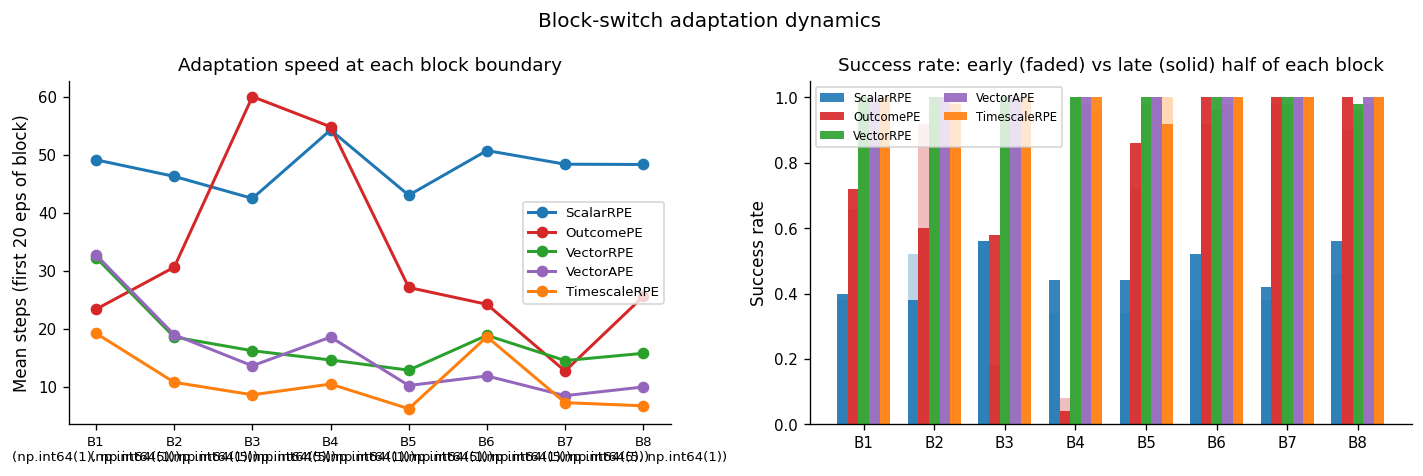

In [19]:
ADAPT_WINDOW = 20

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Block-switch adaptation dynamics', fontsize=12)

# Panel A: steps in the ADAPT_WINDOW episodes after each block switch
ax = axes[0]
for name in MODEL_NAMES:
    steps = arr(f'{name}__steps')
    block_means = []
    for blk in range(N_BLOCKS):
        start = int(block_eps[blk])
        end   = min(start + ADAPT_WINDOW, TOTAL_EPS)
        block_means.append(np.mean(steps[start:end]))
    ax.plot(range(N_BLOCKS), block_means, '-o',
            color=COLORS[name], label=name, lw=1.8, ms=6)

ax.set_xticks(range(N_BLOCKS))
ax.set_xticklabels([f'B{i+1}\n{tuple(block_goals[i])}' for i in range(N_BLOCKS)],
                   fontsize=8)
ax.set_ylabel(f'Mean steps (first {ADAPT_WINDOW} eps of block)')
ax.set_title('Adaptation speed at each block boundary')
ax.legend(fontsize=8)

# Panel B: success rate in first vs last half of each block
ax = axes[1]
half = EPB // 2
x    = np.arange(N_BLOCKS)
w    = 0.15
for mi, name in enumerate(MODEL_NAMES):
    succ = arr(f'{name}__success')
    early_means = [np.mean(succ[int(block_eps[b]):int(block_eps[b])+half]) for b in range(N_BLOCKS)]
    late_means  = [np.mean(succ[int(block_eps[b])+half:int(block_eps[b])+EPB]) for b in range(N_BLOCKS)]
    offset = (mi - 2) * w
    ax.bar(x + offset, late_means, width=w, color=COLORS[name], alpha=0.9, label=name)
    ax.bar(x + offset, early_means, width=w, color=COLORS[name], alpha=0.3)

ax.set_xticks(x)
ax.set_xticklabels([f'B{i+1}' for i in range(N_BLOCKS)])
ax.set_ylabel('Success rate')
ax.set_title('Success rate: early (faded) vs late (solid) half of each block')
ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig('./data/gridworld/fig9_adaptation.pdf', bbox_inches='tight')
plt.show()

## 10  Model comparison summary

/var/folders/x4/111z4lzs6hd77z5pjrh03rm40000gn/T/ipykernel_43743/2594688270.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right')
/var/folders/x4/111z4lzs6hd77z5pjrh03rm40000gn/T/ipykernel_43743/2594688270.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right')
/var/folders/x4/111z4lzs6hd77z5pjrh03rm40000gn/T/ipykernel_43743/2594688270.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right')


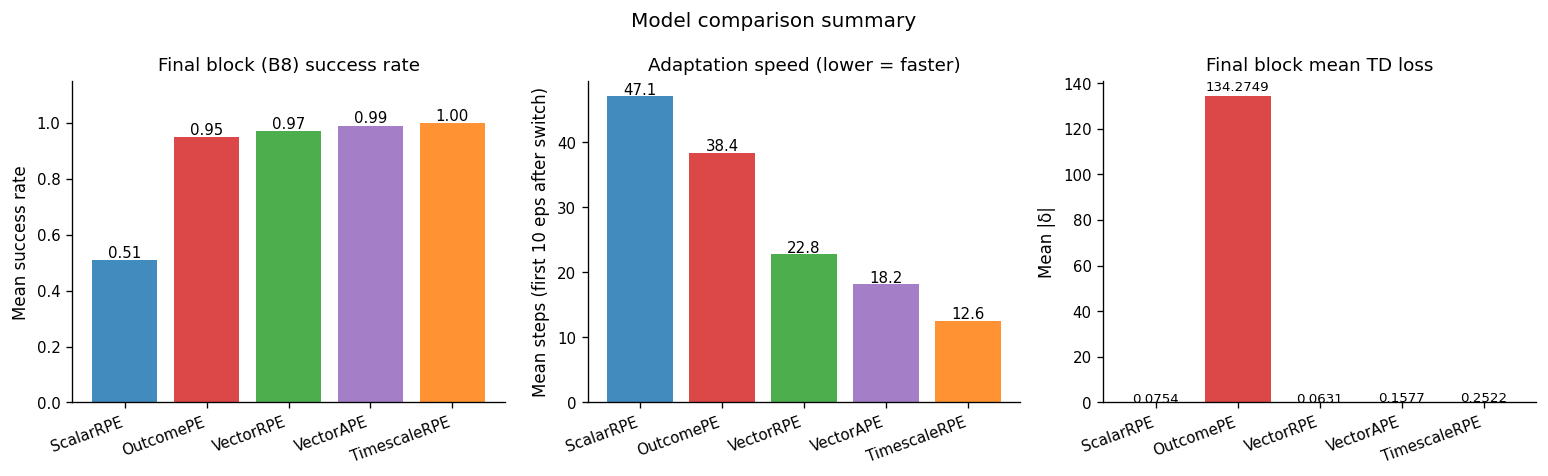

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Model comparison summary', fontsize=12)

# --- Panel A: final-block performance ---
ax = axes[0]
final_success = [np.mean(arr(f'{name}__success')[-EPB:]) for name in MODEL_NAMES]
bars = ax.bar(MODEL_NAMES, final_success,
              color=[COLORS[n] for n in MODEL_NAMES], alpha=0.85)
for bar, v in zip(bars, final_success):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{v:.2f}', ha='center', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Mean success rate')
ax.set_title('Final block (B8) success rate')
ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right')

# --- Panel B: mean steps in first 10 eps after EVERY block switch (proxy for adapt. speed) ---
ax = axes[1]
adapt_steps = []
for name in MODEL_NAMES:
    steps = arr(f'{name}__steps')
    first10 = [np.mean(steps[int(block_eps[b]):int(block_eps[b])+10])
               for b in range(1, N_BLOCKS)]  # skip block 1 (no prior goal)
    adapt_steps.append(np.mean(first10))

bars = ax.bar(MODEL_NAMES, adapt_steps,
              color=[COLORS[n] for n in MODEL_NAMES], alpha=0.85)
for bar, v in zip(bars, adapt_steps):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{v:.1f}', ha='center', fontsize=9)
ax.set_ylabel('Mean steps (first 10 eps after switch)')
ax.set_title('Adaptation speed (lower = faster)')
ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right')

# --- Panel C: mean TD loss in the final block ---
ax = axes[2]
final_loss = [np.mean(arr(f'{name}__td_loss')[-EPB:]) for name in MODEL_NAMES]
bars = ax.bar(MODEL_NAMES, final_loss,
              color=[COLORS[n] for n in MODEL_NAMES], alpha=0.85)
for bar, v in zip(bars, final_loss):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
            f'{v:.4f}', ha='center', fontsize=8)
ax.set_ylabel('Mean |δ|')
ax.set_title('Final block mean TD loss')
ax.set_xticklabels(MODEL_NAMES, rotation=20, ha='right')

plt.tight_layout()
plt.savefig('./data/gridworld/fig10_model_comparison.pdf', bbox_inches='tight')
plt.show()

## 11  Feature representations: weight vectors on the grid

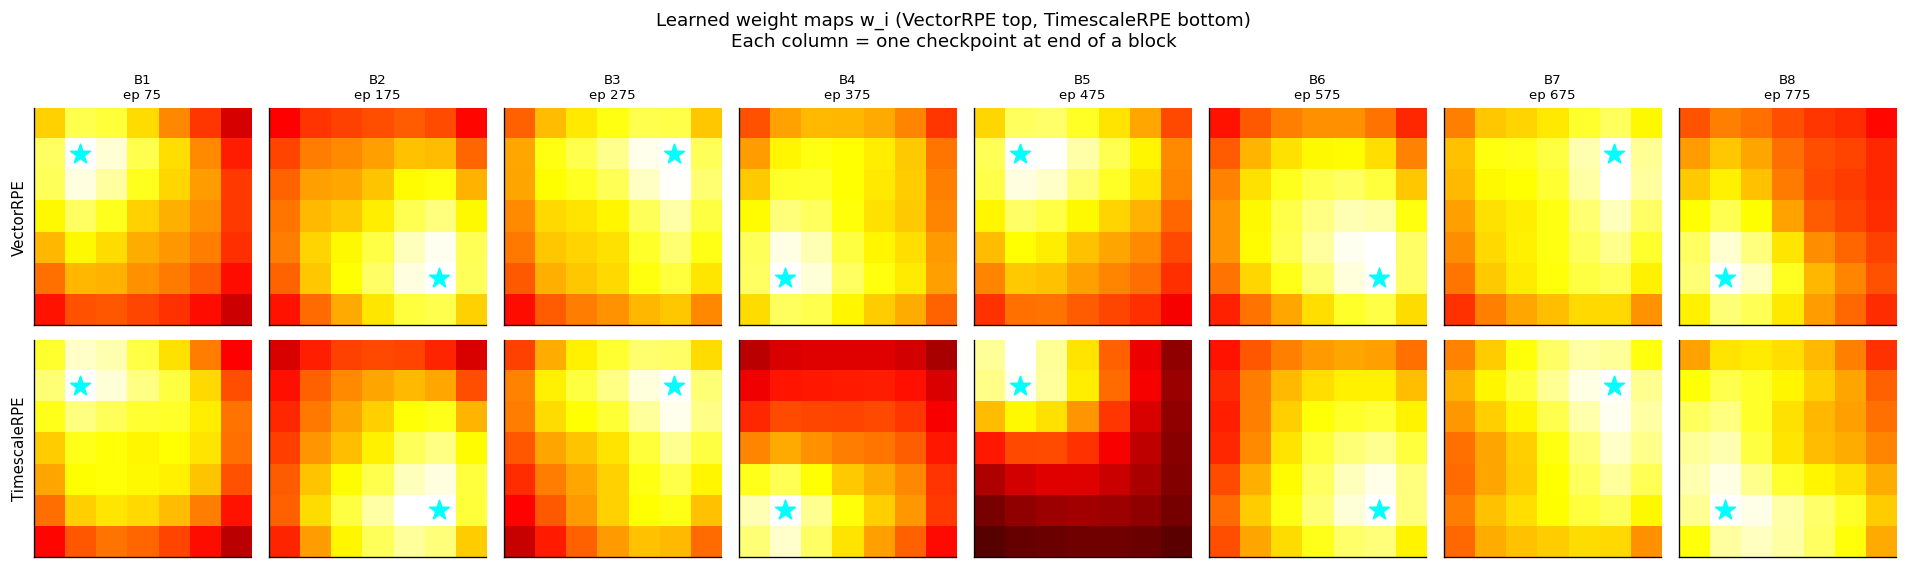

In [21]:
# For VectorRPE and TimescaleRPE, the weights w_i have a spatial interpretation:
# w_i is the 'value association' of the RBF centred at cell i.
# Reshape w into (H, W) to visualise the learned value representation.

fig, axes = plt.subplots(2, N_BLOCKS, figsize=(2*N_BLOCKS, 5))
fig.suptitle('Learned weight maps w_i (VectorRPE top, TimescaleRPE bottom)\n'
             'Each column = one checkpoint at end of a block', fontsize=11)

for blk in range(N_BLOCKS):
    blk_ckpts = ckpts_in_block(blk)
    ci = blk_ckpts[-1]   # end of this block
    ep = checkpoints[ci]
    gr, gc = block_goals[blk]

    for row, (name, cmap) in enumerate([('VectorRPE','hot'),('TimescaleRPE','hot')]):
        ax   = axes[row, blk]
        vmap = arr(f'{name}__val_maps')[ci]
        im   = ax.imshow(vmap, cmap=cmap, origin='upper', vmin=0)
        ax.scatter([gc],[gr],marker='*',s=150,c='cyan',zorder=5)
        ax.set_xticks([]); ax.set_yticks([])
        if blk == 0: ax.set_ylabel(name, fontsize=9)
        if row == 0: ax.set_title(f'B{blk+1}\nep {ep}', fontsize=8)

plt.tight_layout()
plt.savefig('./data/gridworld/fig11_weight_maps.pdf', bbox_inches='tight')
plt.show()

## 12  β vs value: scatter plot of β_i vs w_i at final checkpoint
Shows what the β-update learns relative to the value weights.

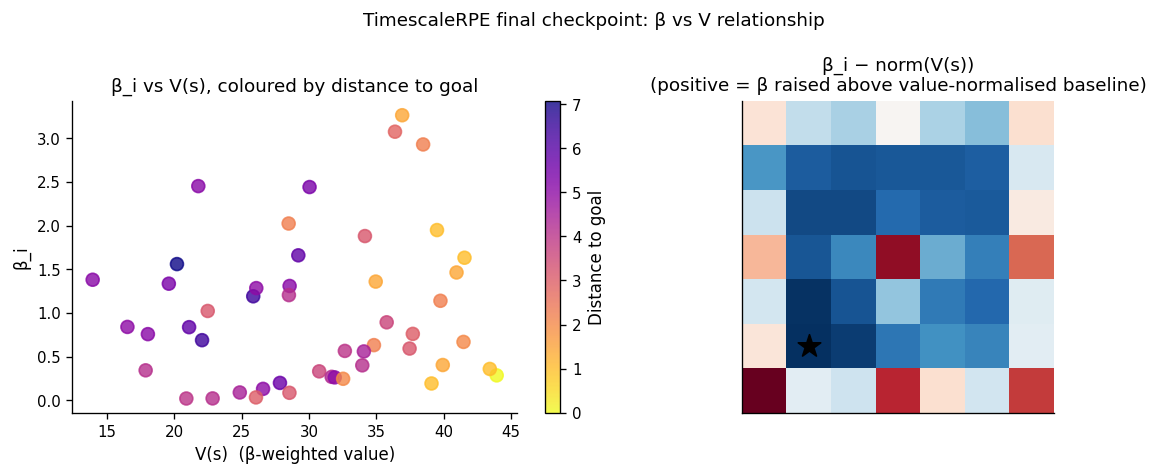

In [22]:
ci_f  = len(checkpoints) - 1
vmap  = arr('TimescaleRPE__val_maps')[ci_f]      # H×W
bmap  = arr('TimescaleRPE__beta_maps')[ci_f]     # H×W

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('TimescaleRPE final checkpoint: β vs V relationship', fontsize=11)

# Flatten and colour by distance to goal
gr, gc = block_goals[-1]
dists  = np.array([np.sqrt((r-gr)**2+(c-gc)**2)
                   for r in range(H) for c in range(W)])
sc = axes[0].scatter(vmap.ravel(), bmap.ravel(), c=dists,
                      cmap='plasma_r', alpha=0.8, s=60)
axes[0].set_xlabel('V(s)  (β-weighted value)')
axes[0].set_ylabel('β_i')
axes[0].set_title('β_i vs V(s), coloured by distance to goal')
plt.colorbar(sc, ax=axes[0], label='Distance to goal')

# Side-by-side maps
axes[1].imshow(bmap - vmap/vmap.max(), cmap='RdBu_r', origin='upper')
axes[1].scatter([gc],[gr],marker='*',s=200,c='black',zorder=5)
axes[1].set_title('β_i − norm(V(s))\n(positive = β raised above value-normalised baseline)')
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.savefig('./data/gridworld/fig12_beta_vs_value.pdf', bbox_inches='tight')
plt.show()